<a href="https://colab.research.google.com/github/ascot119-rgb/Alex-s-Projects/blob/main/4105_Assignment_1_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iteration: 0
Current parameters: 0.018597, 0.089220, 0.058631
Current intercept: 0.000000
Current cost: 5.524438
Iteration: 100
Current parameters: -1.293069, 1.170078, 0.307664
Current intercept: 0.000000
Current cost: 1.714019
Iteration: 200
Current parameters: -1.503649, 1.103316, 0.238337
Current intercept: 0.000000
Current cost: 1.384695
Iteration: 300
Current parameters: -1.600763, 1.002808, 0.151159
Current intercept: 0.000000
Current cost: 1.171969
Iteration: 400
Current parameters: -1.674221, 0.917897, 0.076167
Current intercept: 0.000000
Current cost: 1.029304
Iteration: 500
Current parameters: -1.733880, 0.848195, 0.014375
Current intercept: 0.000000
Current cost: 0.933589
Iteration: 600
Current parameters: -1.782702, 0.791094, -0.036273
Current intercept: 0.000000
Current cost: 0.869374
Iteration: 700
Current parameters: -1.822687, 0.744322, -0.077761
Current intercept: 0.000000
Current cost: 0.826292
Iteration: 800
Current parameters: -1.855438, 0.706012, -0.111744
Current

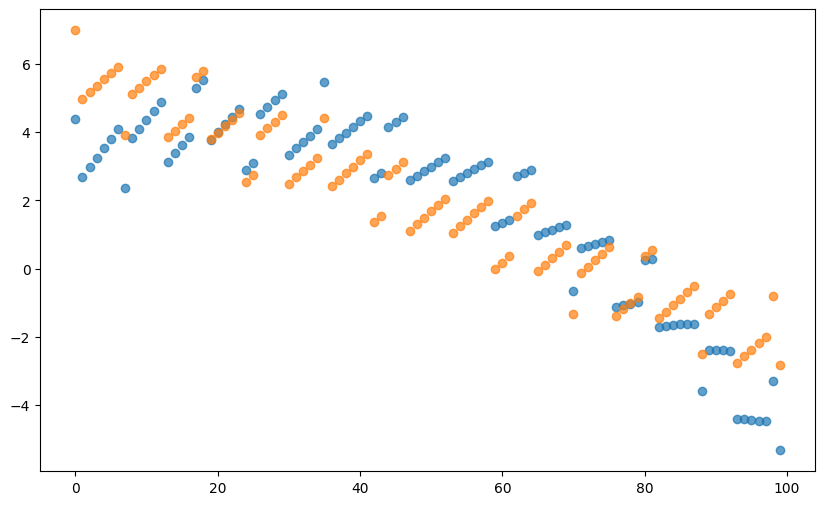

Total iterations: 1979


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

filepath = "/content/D3.csv"

df = pd.read_csv(filepath)

index = np.arange(0, 100)
x1 = df.values[:, 0]
x2 = df.values[:, 1]
x3 = df.values[:, 2]
y = df.values[:, 3]
m = len(y)
n = len(x1)

size = 4

cf = 10
lr = 0.02
params = np.zeros(size)
x_val = [x1, x2, x3]

def cost_function(res, y):
  return np.sum((res - y) ** 2) / (2 * m)

def plot_result_to_target(index, result, y, x):
  plt.figure(figsize=(10, 6))
  plt.scatter(index, y, label='Index vs Y', alpha=0.7)
  plt.scatter(index, result, label='Index vs Result', alpha=0.7)
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(size)
  for ind in range(len(params) - 1):
    temp[ind] = np.sum((result - y) * x[ind]) / m
  temp[len(params) - 1] = np.sum(result - y) / m
  return temp

def linearfun(data, params, inter):
  ans = np.zeros(len(data[0]))
  for i in range(len(params) - 1):
    ans += params[i] * data[i]
  return ans + params[len(params) - 1]


def linregression(data, params, y):
  grad = np.ones(len(params))
  iteration = 0
  while any(abs(x) > 0.01 for x in grad):
    result = linearfun(data, params, inter)
    cf = cost_function(result, y)
    #Only plot if you want to see the progress at each step, can be computationally intensive
    grad = gradient(result, y, data)
    for i in range(len(params)):
      params[i] = params[i] - lr * grad[i]
    if iteration % 100 == 0:
      print(f"Iteration: {iteration}")
      print(f"Current parameters: {params[0]:.6f}, {params[1]:.6f}, {params[2]:.6f}, {params[3]:.6f}")
      print(f"Current cost: {cf:.6f}")
    iteration += 1
  plot_result_to_target(index, result, y, data)
  print(f"Total iterations: {iteration}")
  iteration = 0


linregression(x_val, params, y)